<a href="https://colab.research.google.com/github/tripathiosho/ImportantNotebooks/blob/main/Lecture6_GMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

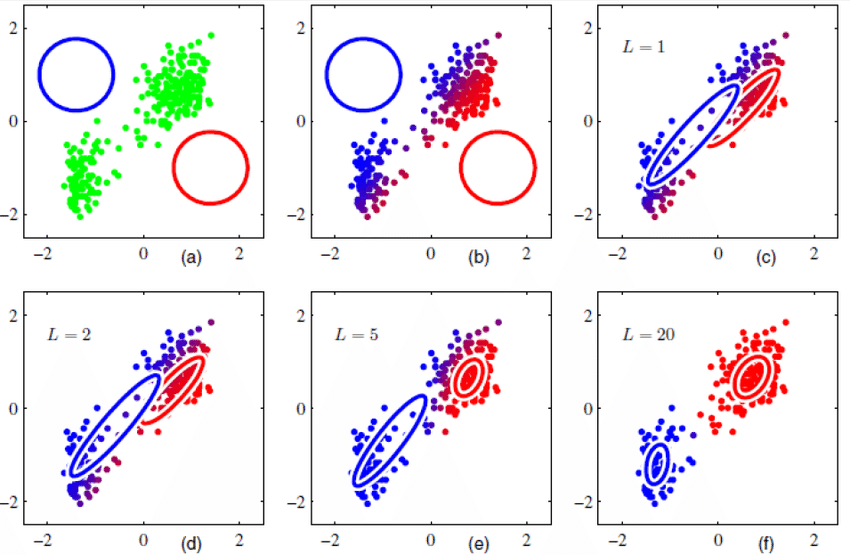

## Code Walkthrough

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (16,12)

In [ ]:
!wget "https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W" -O E-commerce.csv

--2025-10-06 17:27:41--  https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W
Resolving drive.google.com (drive.google.com)... 172.253.63.138, 172.253.63.102, 172.253.63.101, ...
Connecting to drive.google.com (drive.google.com)|172.253.63.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download [following]
--2025-10-06 17:27:42--  https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.163.132, 2607:f8b0:4004:c1b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.163.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 139827 (137K) [application/octet-stream]
Saving to: ‘E-commerce.csv’

E-commerce.csv      100%[===================>] 136.55K  --.-KB/

In [ ]:
df = pd.read_csv('./E-commerce.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2500 non-null   int64  
 1   n_clicks                 2500 non-null   int64  
 2   n_visits                 2500 non-null   int64  
 3   amount_spent             2500 non-null   float64
 4   amount_discount          2500 non-null   float64
 5   days_since_registration  2500 non-null   int64  
 6   profile_information      2500 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 136.8 KB


In [ ]:
df.head()

,ID,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,1476,130,65,213.905831,31.600751,233,235
1,1535,543,46,639.223004,5.689175,228,170
2,1807,520,102,1157.402763,844.321606,247,409
3,1727,702,83,1195.903634,850.041757,148,200
4,1324,221,84,180.754616,64.283300,243,259


In [ ]:
df.drop('ID',axis=1,inplace=True)

In [ ]:
std_scaler = StandardScaler().fit(df)
std_df = std_scaler.transform(df)

In [ ]:
std_df = pd.DataFrame(std_df,columns=df.columns)

std_df.head()

,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,-1.495250,-0.758535,-1.054611,-0.732800,0.323118,0.339192
1,0.720691,-1.247488,-0.690292,-0.786002,0.272672,-0.310034
2,0.597285,0.193635,-0.246428,0.935872,0.464365,2.077120
3,1.573801,-0.295317,-0.213449,0.947616,-0.534456,-0.010392
4,-1.006992,-0.269583,-1.083008,-0.665697,0.424009,0.578906


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(2)

components = pca.fit_transform(std_df)

x_1 = components[:,0]
x_2 = components[:,1]

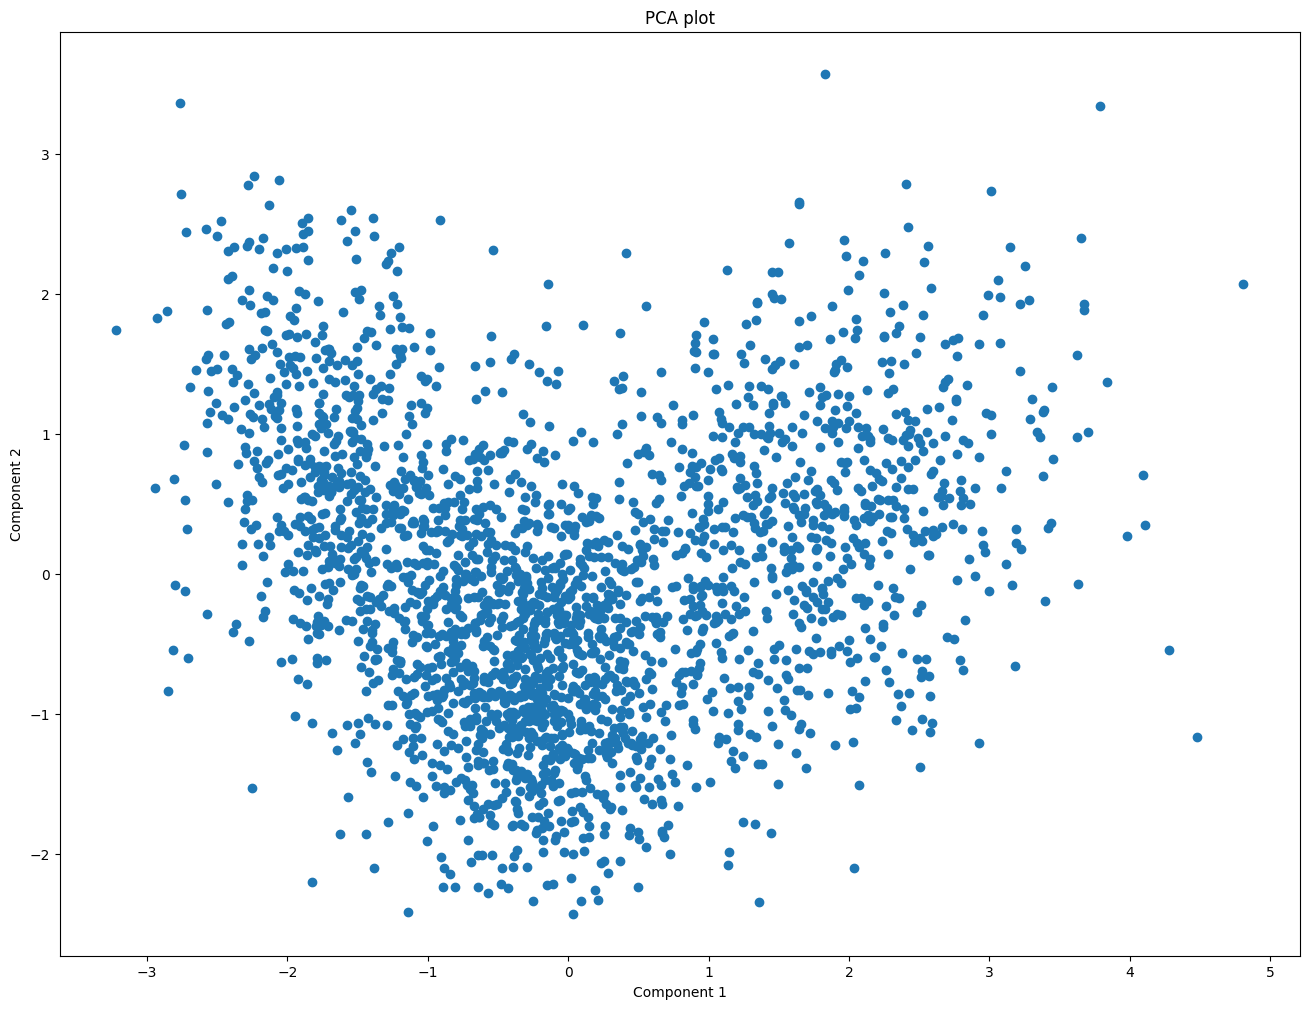

In [ ]:
plt.scatter(x_1,x_2)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("PCA plot")
plt.show()

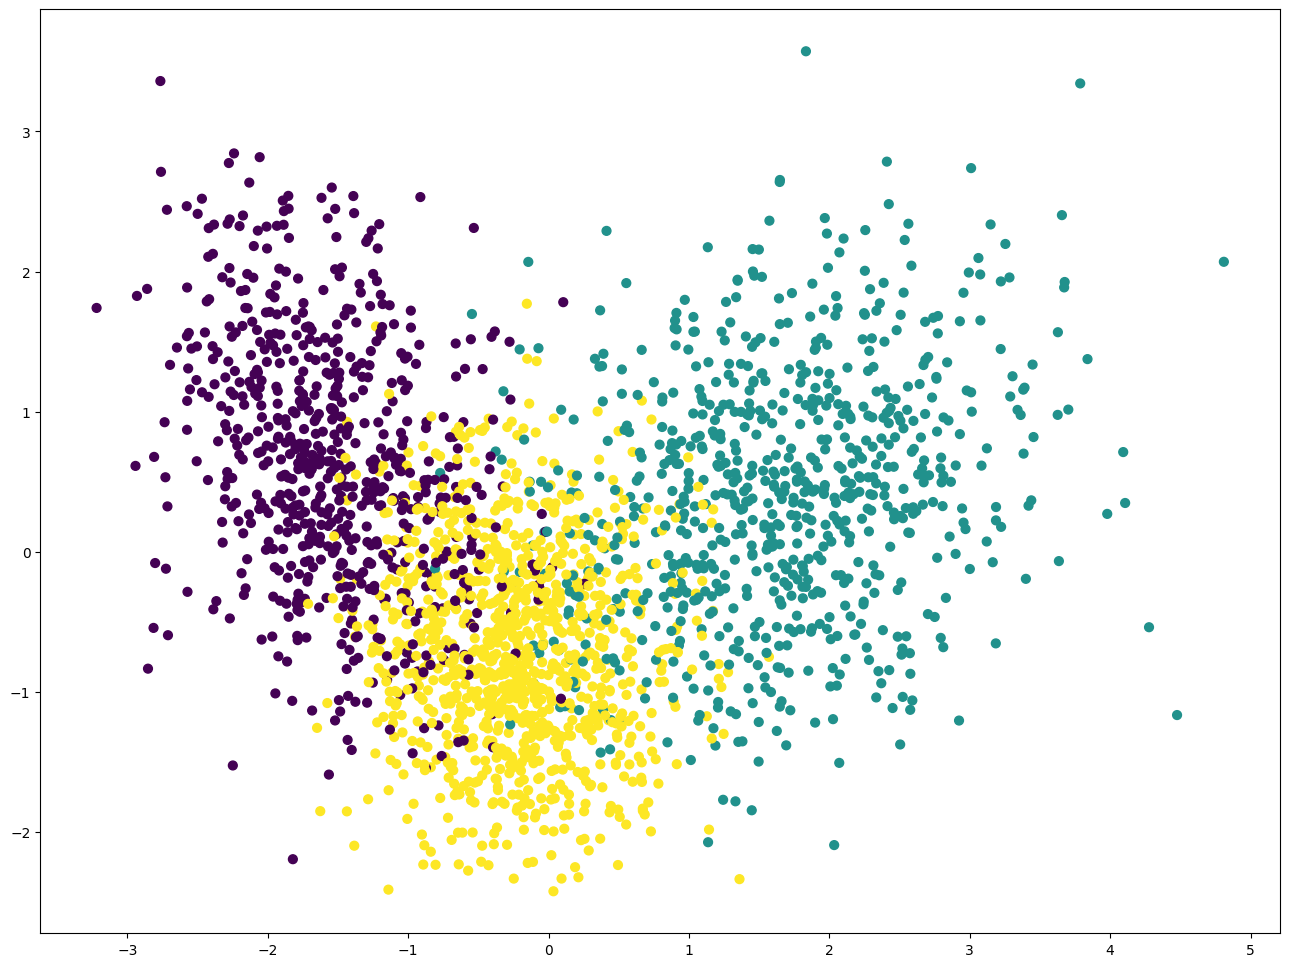

In [ ]:
from sklearn.mixture import GaussianMixture


gmm = GaussianMixture(n_components=3).fit(std_df)

labels = gmm.predict(std_df)

plt.scatter(x_1, x_2, c=labels, s=40, cmap='viridis');

In [ ]:
from sklearn.manifold import TSNE

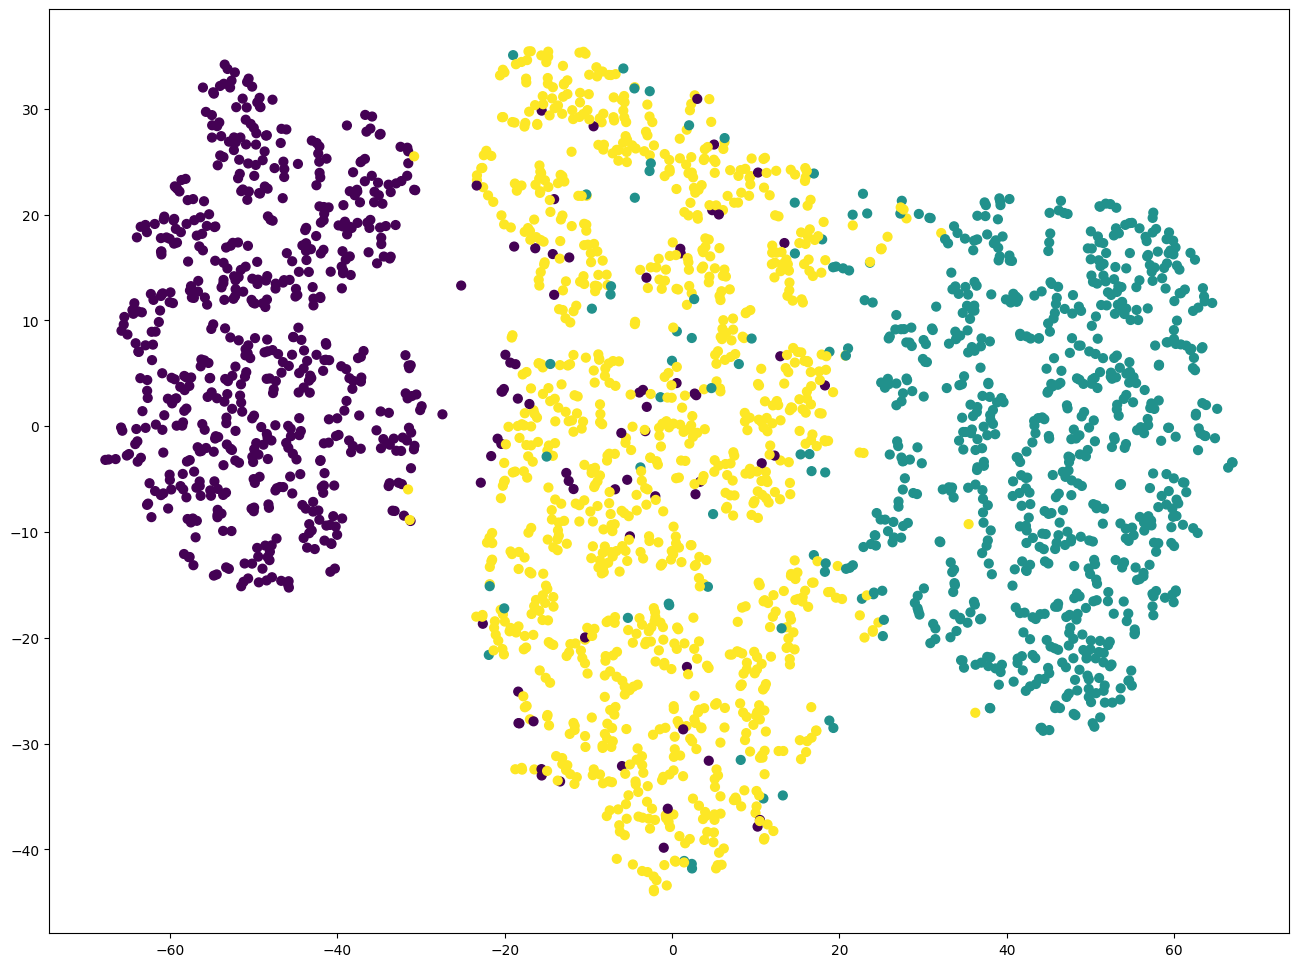

In [ ]:
tsne = TSNE()

transformed_df = tsne.fit_transform(std_df)

tsne_x_1 = transformed_df[:,0]
tsne_x_2 = transformed_df[:,1]

plt.scatter(tsne_x_1, tsne_x_2, c=labels, s=40, cmap='viridis');

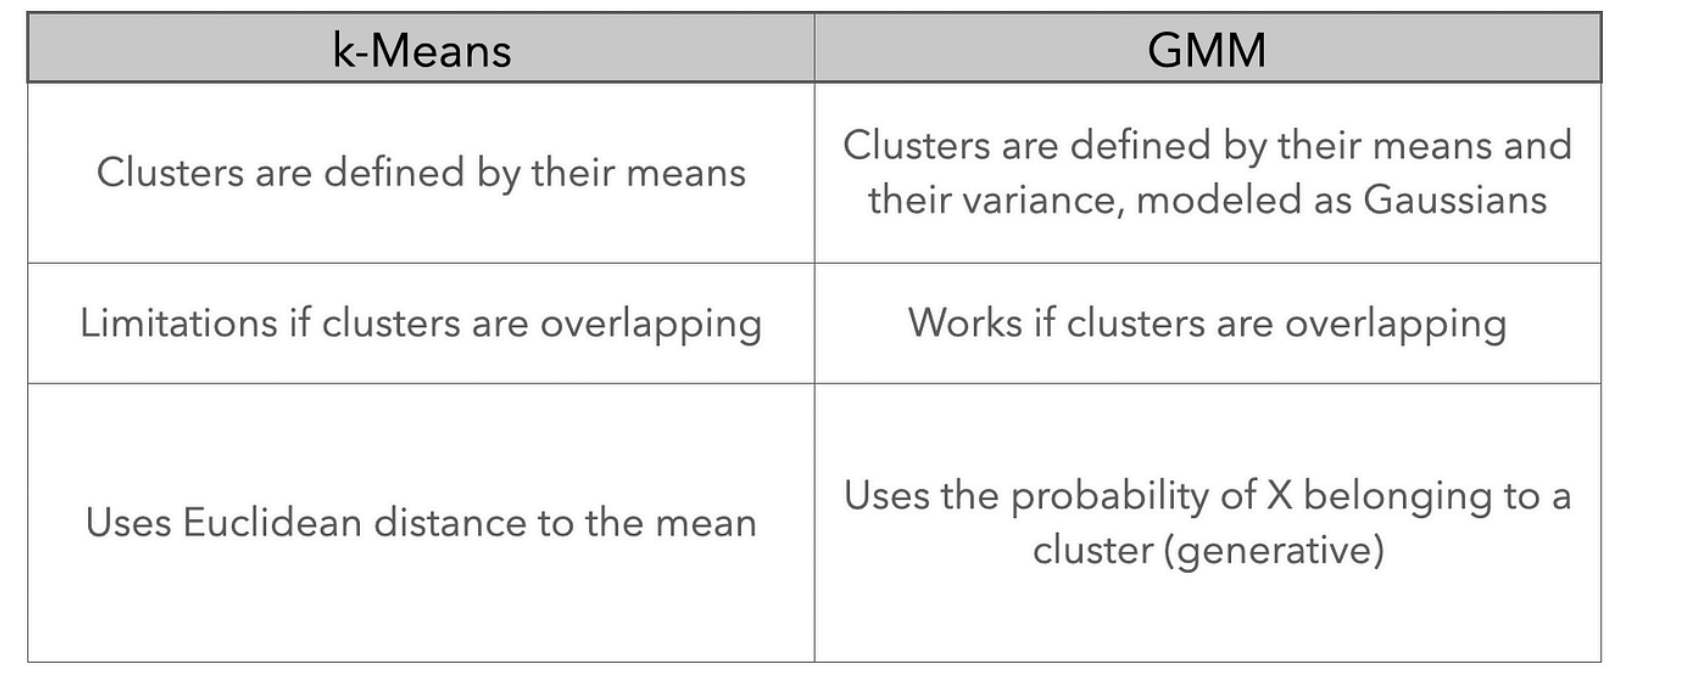

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

In [ ]:
# Set random seed for reproducibility
np.random.seed(21)

In [ ]:
# Generate synthetic data
n_samples = 1500

In [ ]:
# Define parameters for three Gaussian clusters
mean1 = [-2, 2]
cov1 = [[1, 0.9], [0.9, 1]]  # High correlation
mean2 = [5, 5]
cov2 = [[1, 0], [0, 1]]  # No correlation
mean3 = [-5, 5]
cov3 = [[1, -0.8], [-0.8, 1]]  # Negative correlation

In [ ]:
# Generate points for each cluster
X1 = np.random.multivariate_normal(mean1, cov1, n_samples // 3)
X2 = np.random.multivariate_normal(mean2, cov2, n_samples // 3)
X3 = np.random.multivariate_normal(mean3, cov3, n_samples // 3)

# Combine the points to create the dataset
X = np.vstack((X1, X2, X3))

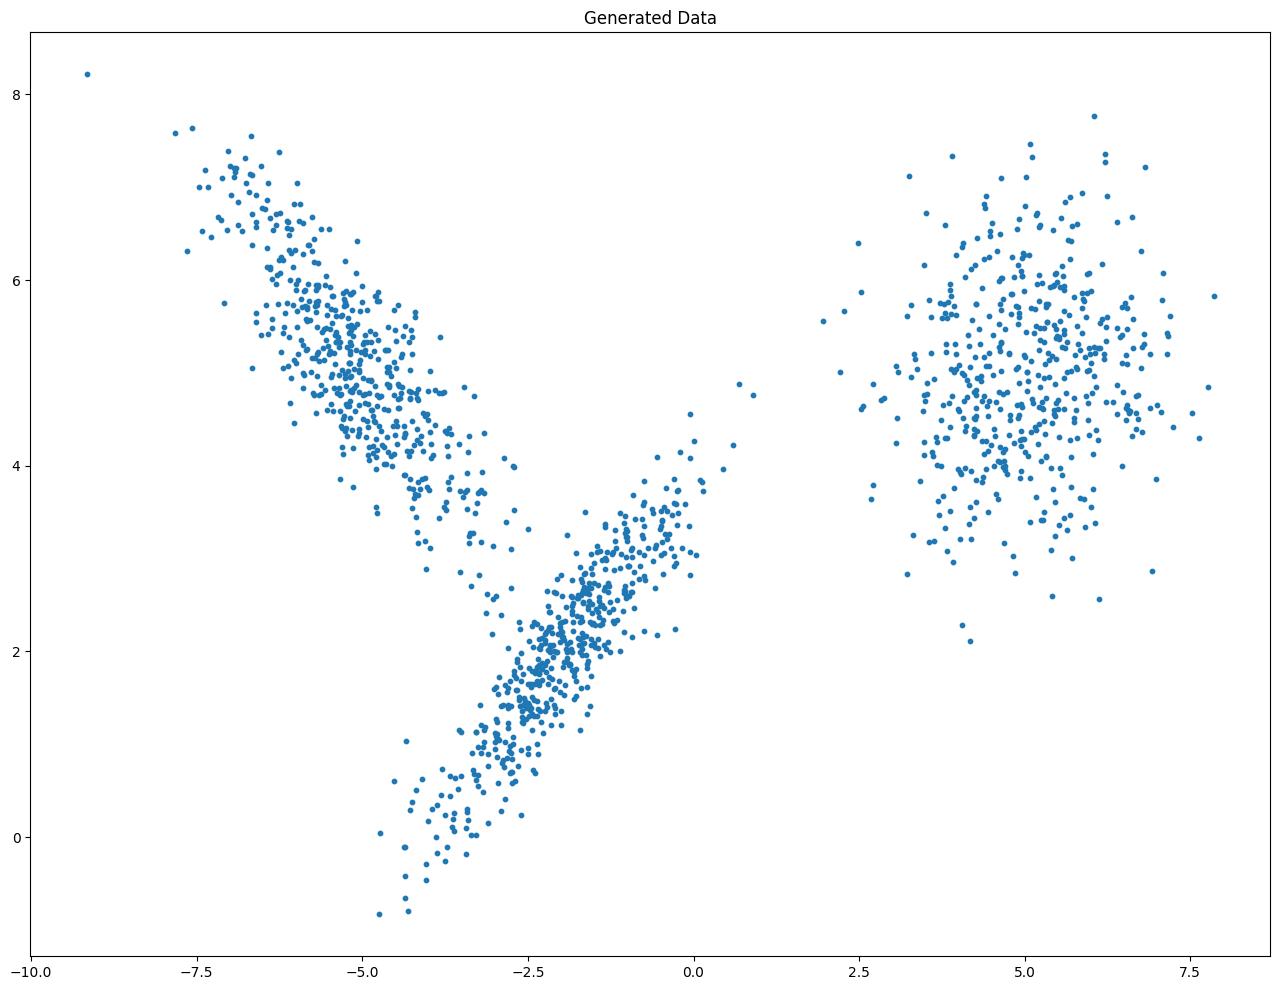

In [ ]:
# Plot the generated data
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title("Generated Data")
plt.show()

In [ ]:
# Fit a GMM model
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)

In [ ]:
# Fit a K-means model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

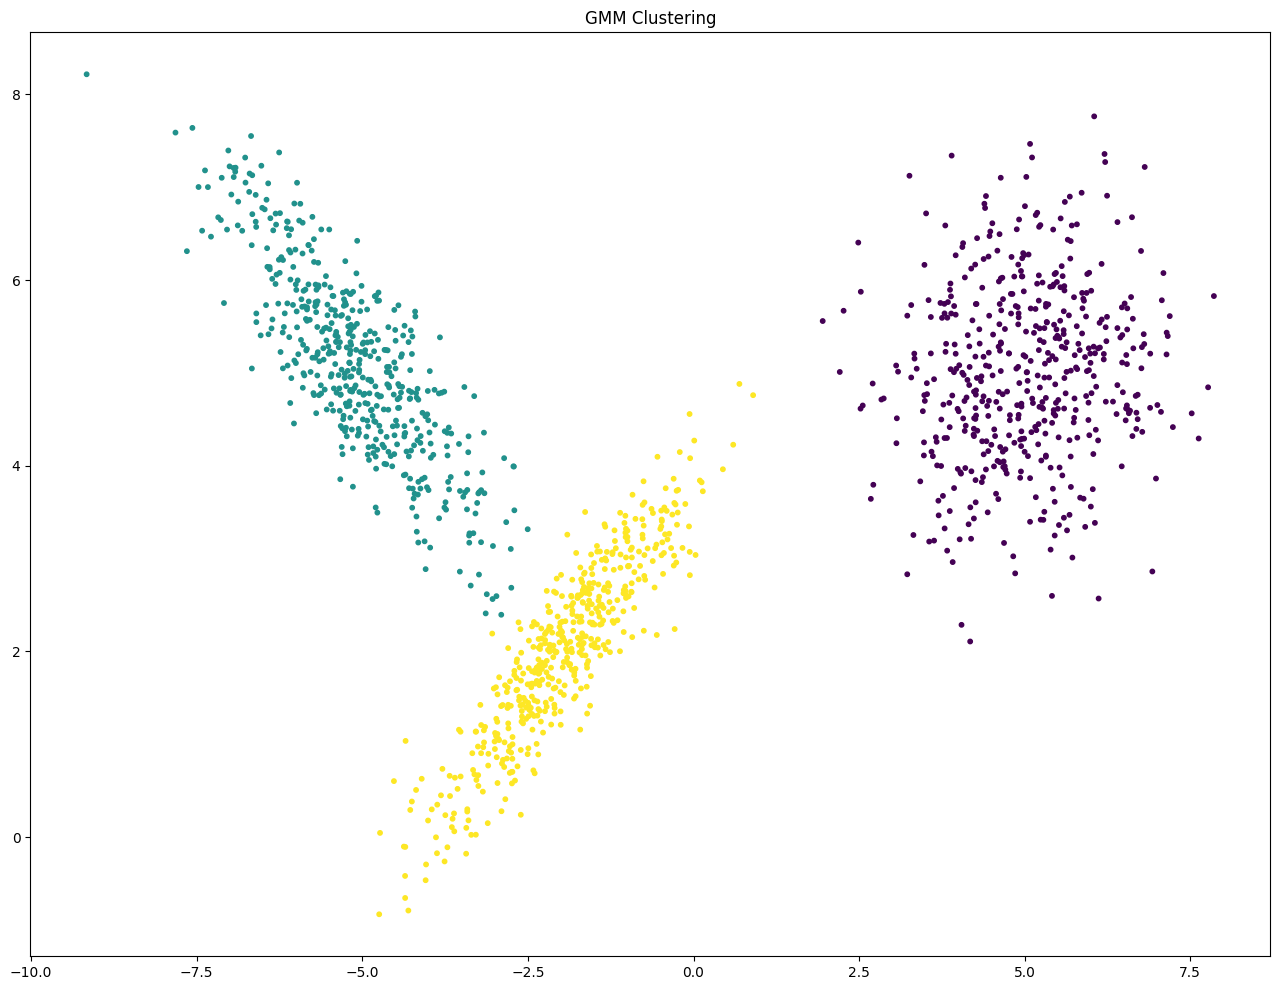

In [ ]:
# Plot GMM clustering results
plt.scatter(X[:, 0], X[:, 1], c=gmm_labels, s=10, cmap='viridis')
plt.title("GMM Clustering")
plt.show()

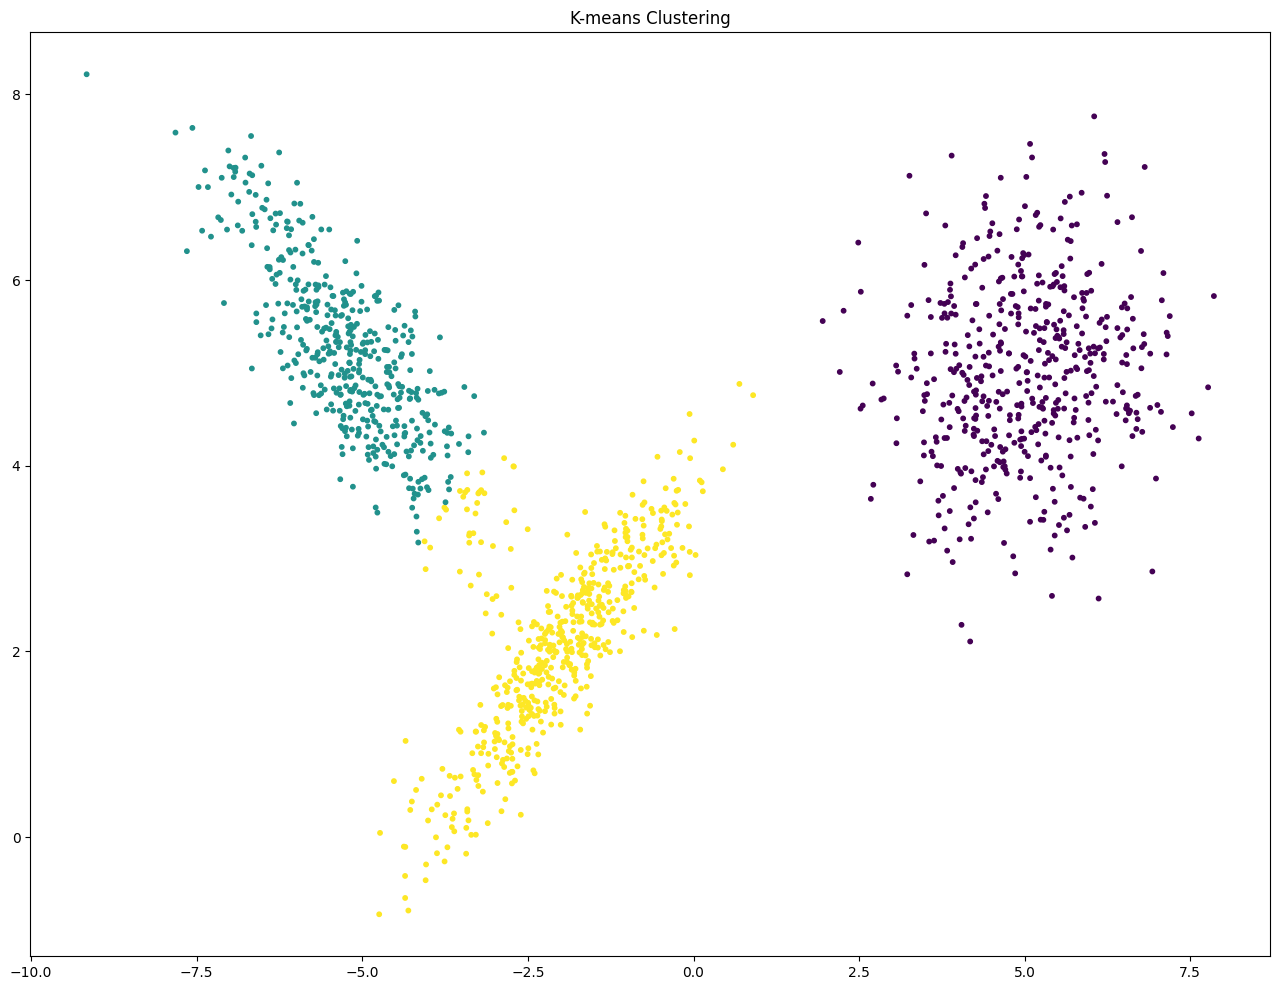

In [ ]:
# Plot K-means clustering results
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, s=10, cmap='viridis')
plt.title("K-means Clustering")
plt.show()

## Doubts

## ML1 Topics

1. Linear Regression
  - Basic concept of LR. How does it work.
  - Feature Importance
  - Bias and Variance
  - Regularization (L1,L2, L1 Vs L2)
  - Loss function
  - Evaluation Metrics

2. Logistic Regression
  - How do it work.
  - loss function
  - Evaluation Metrics(CM, Recall vs precison, F1-score). When to use what?

3. KNN
  - Is scaling required?
  - How does this algorithm work?
  - Training time?

4. DT
  - Entropy Vs Gini
  - Information gain
  - Is scaling required for DT?
  - How does the Descion Boundary look like in DT?

5. Ensemble
  - bagging and Boosting
  - Random forest --> How does it work
  - Boosting --> Study any boosting Algo (Typically GBDT)

6. Naive Bayes
  - Suty some examples of this algo.

7. SVM
  - mathematics of SVM.
  - Kernal Function
  - RBF
  

In [ ]:
x